Updated model to modify for normalization N and baseline B.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [98]:
real_deconv_combined.save_replication_deconvolution()

Creating directory: data/copy_correction/...Directory exists. Skipping.
Saved to: data/copy_correction//N_combined.npy
Saved to: data/copy_correction//B_combined.npy
Saved to: data/copy_correction//F_combined.npy


In [518]:
from src.GenomeDeconvolution import GenomeDeconvolution

genome_deconvolution = GenomeDeconvolution(save_dir=None)

todo: Copy correction is not in place


In [590]:
from src.RealDataReplication import read_n_fr_b

chrom = 16
deconv_span = 770500, 772000

N, fr, b = read_n_fr_b(chrom, deconv_span)
genome_deconvolution.load_chrom_span(chrom, deconv_span)


Loading chromosome reads: 16
Applying a normalization for length distribution
Loading chromosome reads: 16
Applying a normalization for length distribution
Adding a deconvolution offset to G: 1


In [591]:
genome_deconvolution.combined_model.deconvolve(N=N, f_replication=fr, b=b)

Adding a deconvolution offset to G: 1
Deconvolving combined model with gamma=0.1
Deconvolving bin size: 10x10
of G shape: (31, 3900)
Padding type: both
Deconvolving with gamma=0.1
0/3900 - 00:00:00.128
500/3900 - 00:00:57.978
1000/3900 - 00:01:55.826
1500/3900 - 00:02:50.325
2000/3900 - 00:03:47.596
2500/3900 - 00:04:47.688
3000/3900 - 00:05:58.484
3500/3900 - 00:06:59.742
Deconvolved in : 00:07:48.356
The fitting norm is 4.07, the smoothing norm is: 2.35


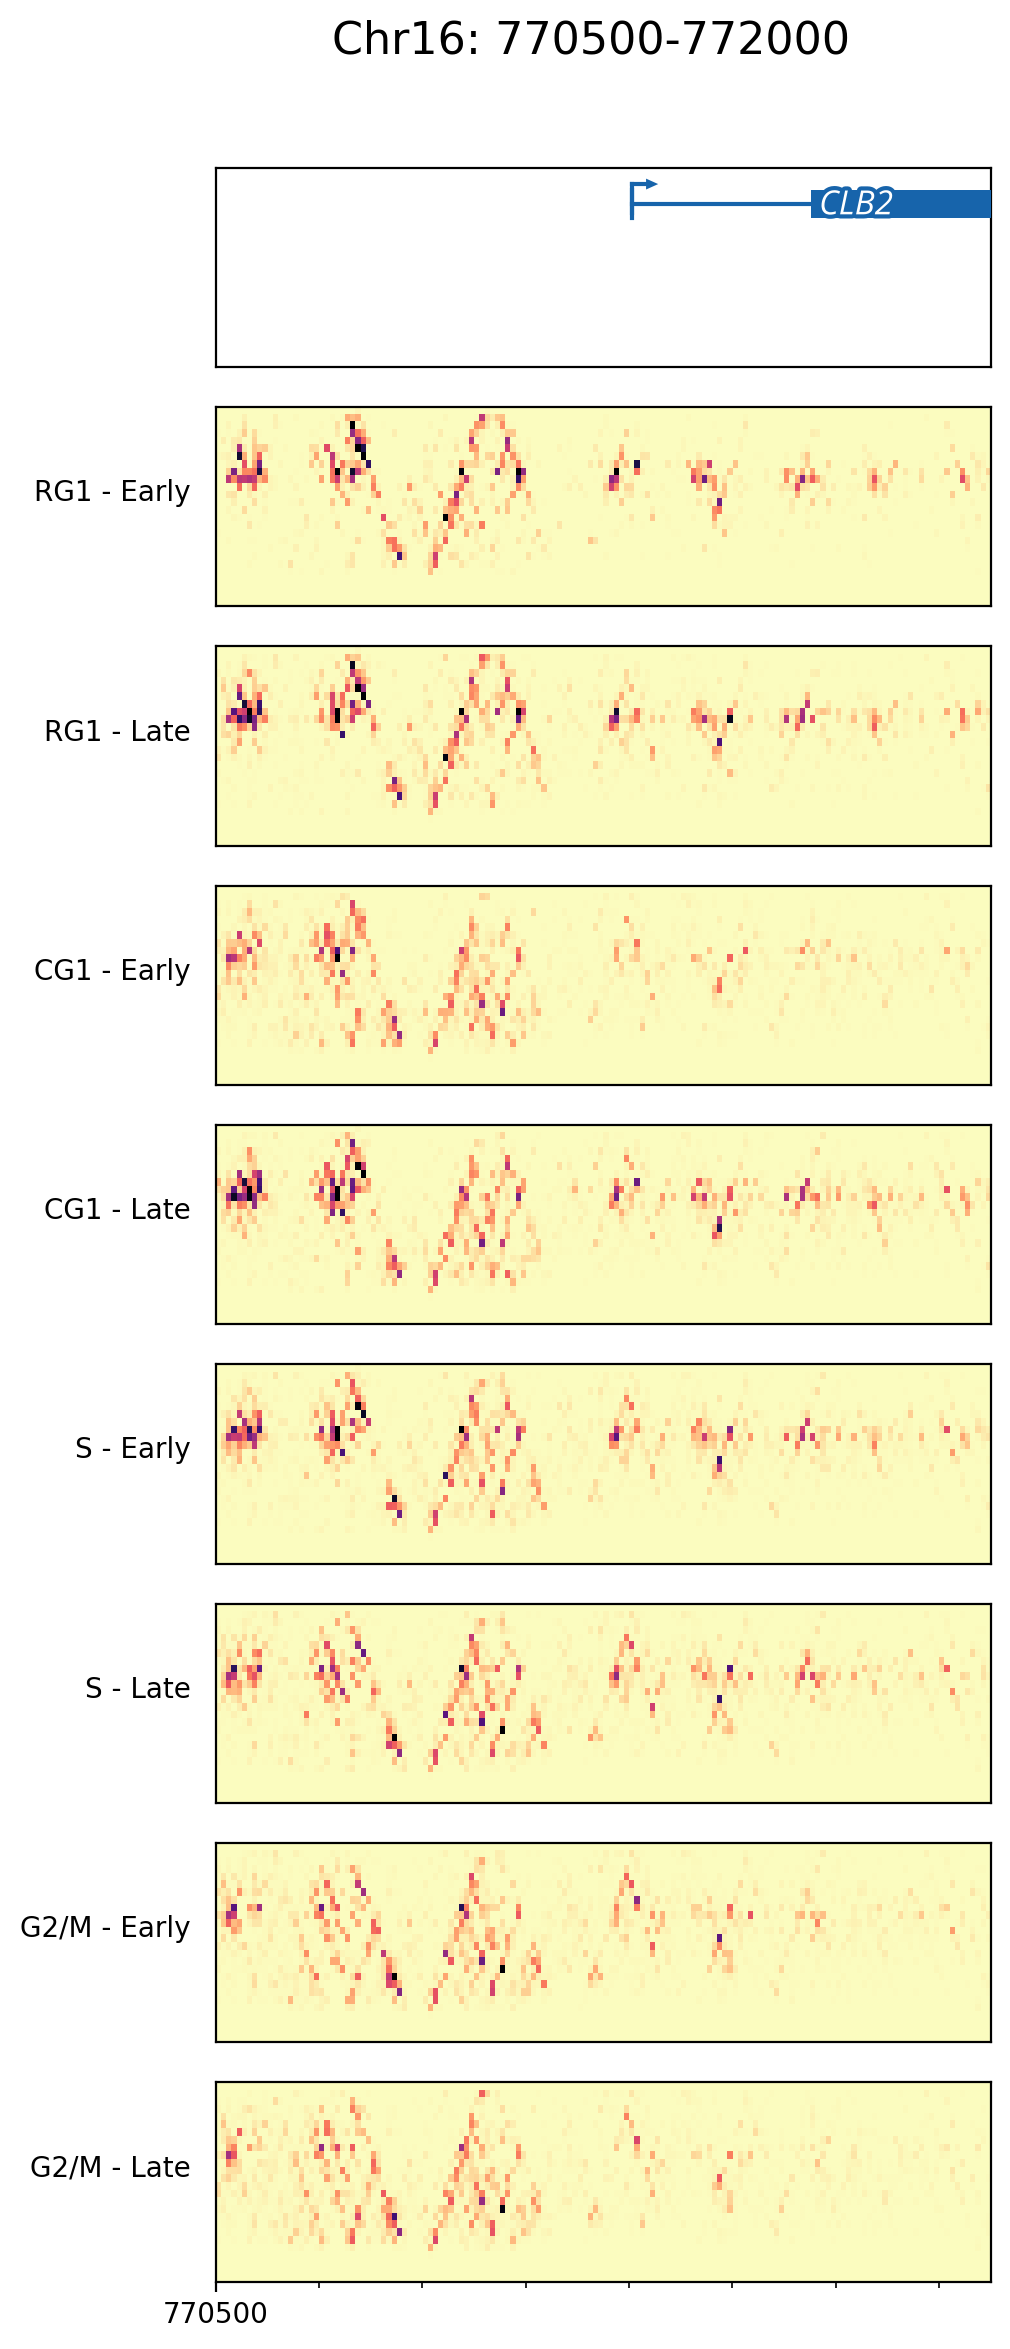

In [592]:
fig = genome_deconvolution.plot_deconvolved_result(figwidth=5, vmin=0.75, vmax=20)

In [578]:
genome_deconvolution_no_cc = GenomeDeconvolution(save_dir=None)

In [585]:
from src.RealDataReplication import read_n_fr_b, read_no_copy_correction_n_fr_b

chrom = 16
deconv_span = 770500, 772000

#genome_deconvolution_no_cc.load_chrom_span(chrom, deconv_span)

H = genome_deconvolution_no_cc.combined_model.H
N, fr, b = read_no_copy_correction_n_fr_b(H)


In [586]:
genome_deconvolution_no_cc.combined_model.deconvolve(N=N, f_replication=fr, b=b)

Adding a deconvolution offset to G: 1
Deconvolving combined model with gamma=0.1
Deconvolving bin size: 10x10
of G shape: (31, 3900)
Padding type: both
Deconvolving with gamma=0.1
0/3900 - 00:00:00.134
500/3900 - 00:00:56.472
1000/3900 - 00:01:48.381
1500/3900 - 00:02:41.824
2000/3900 - 00:03:35.311
2500/3900 - 00:04:28.679
3000/3900 - 00:05:23.641
3500/3900 - 00:06:21.401
Deconvolved in : 00:07:04.516
The fitting norm is 2.40, the smoothing norm is: 2.69


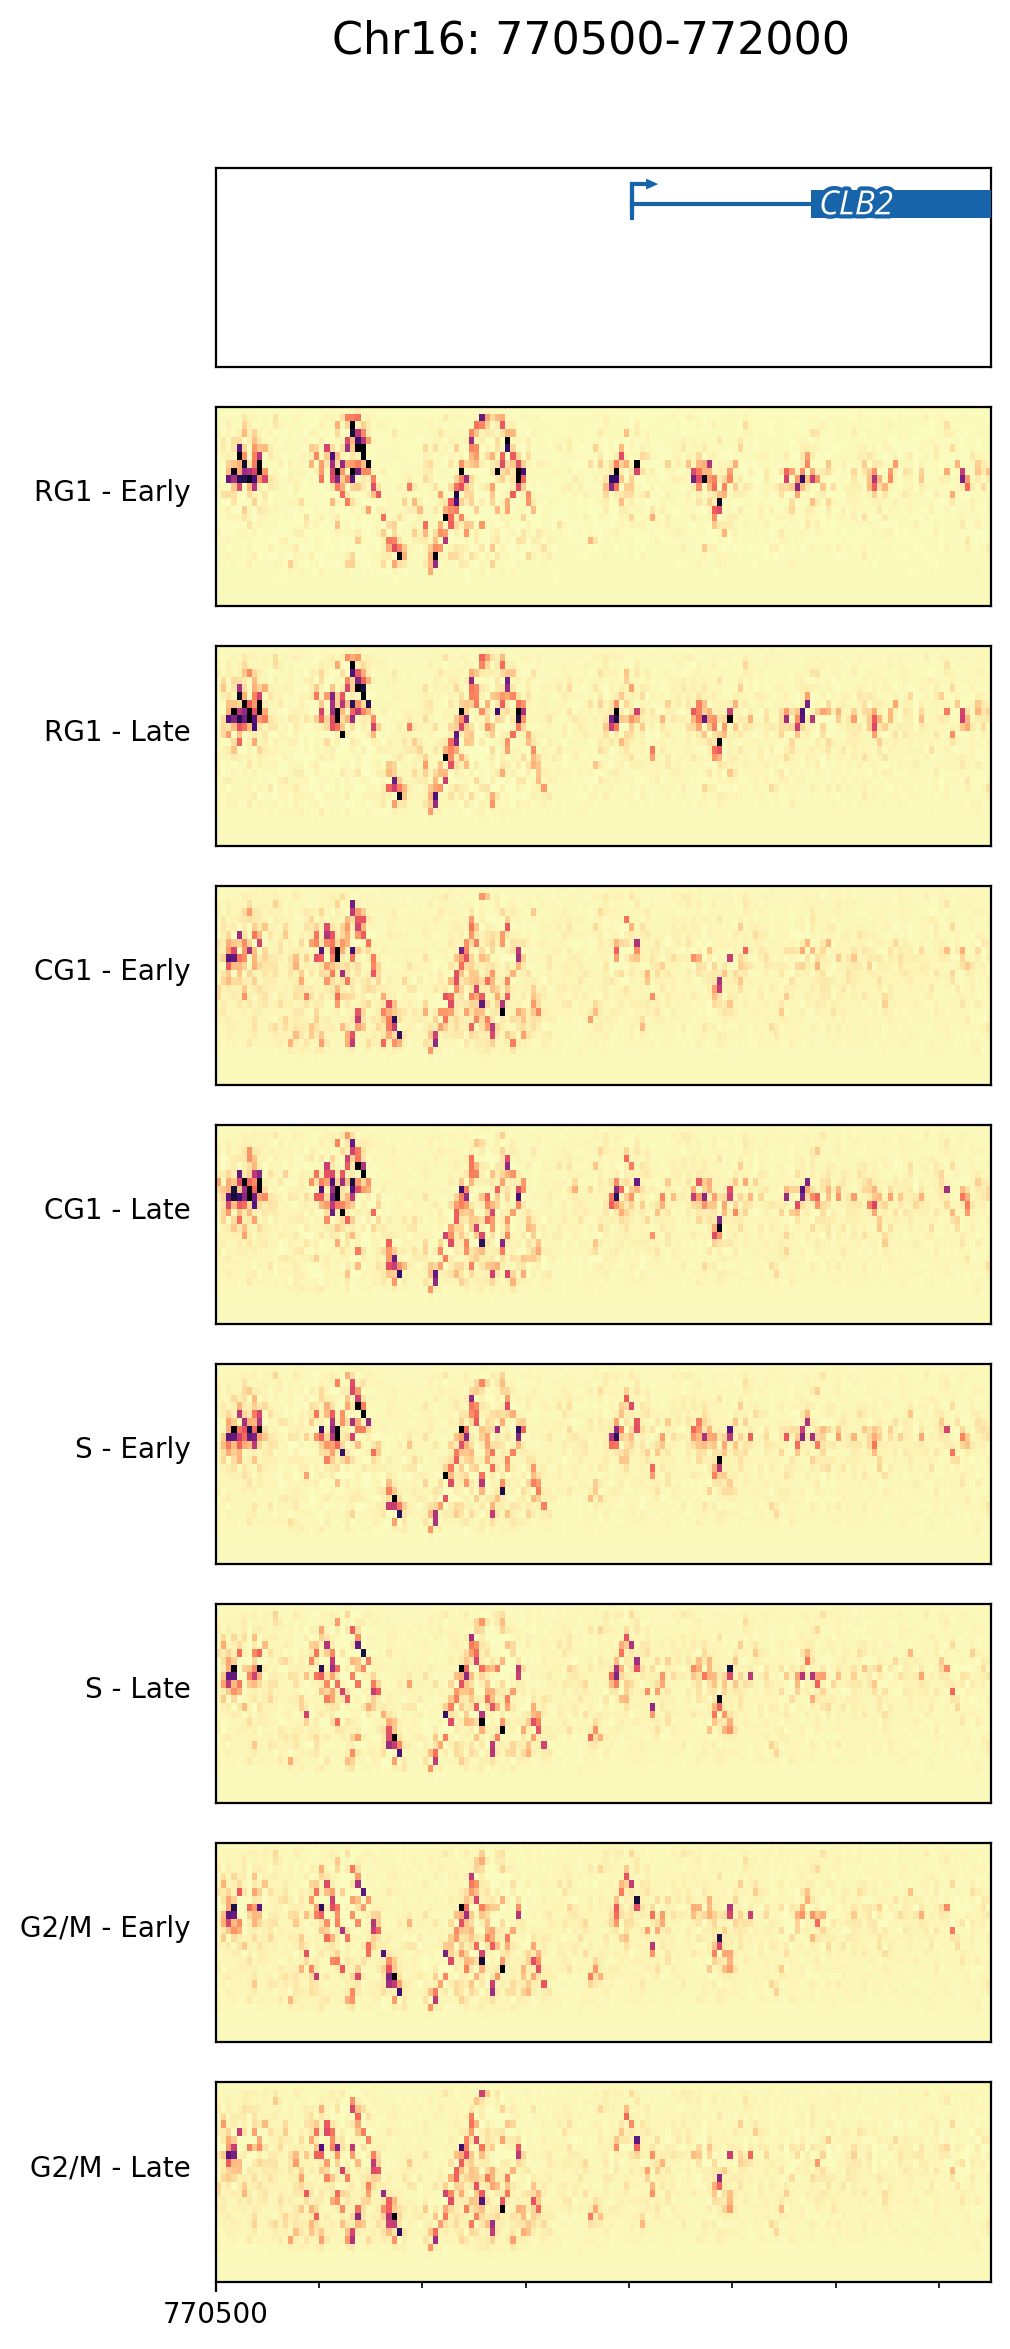

In [588]:
fig = genome_deconvolution_no_cc.plot_deconvolved_result(figwidth=5, vmin=0.75, vmax=20)

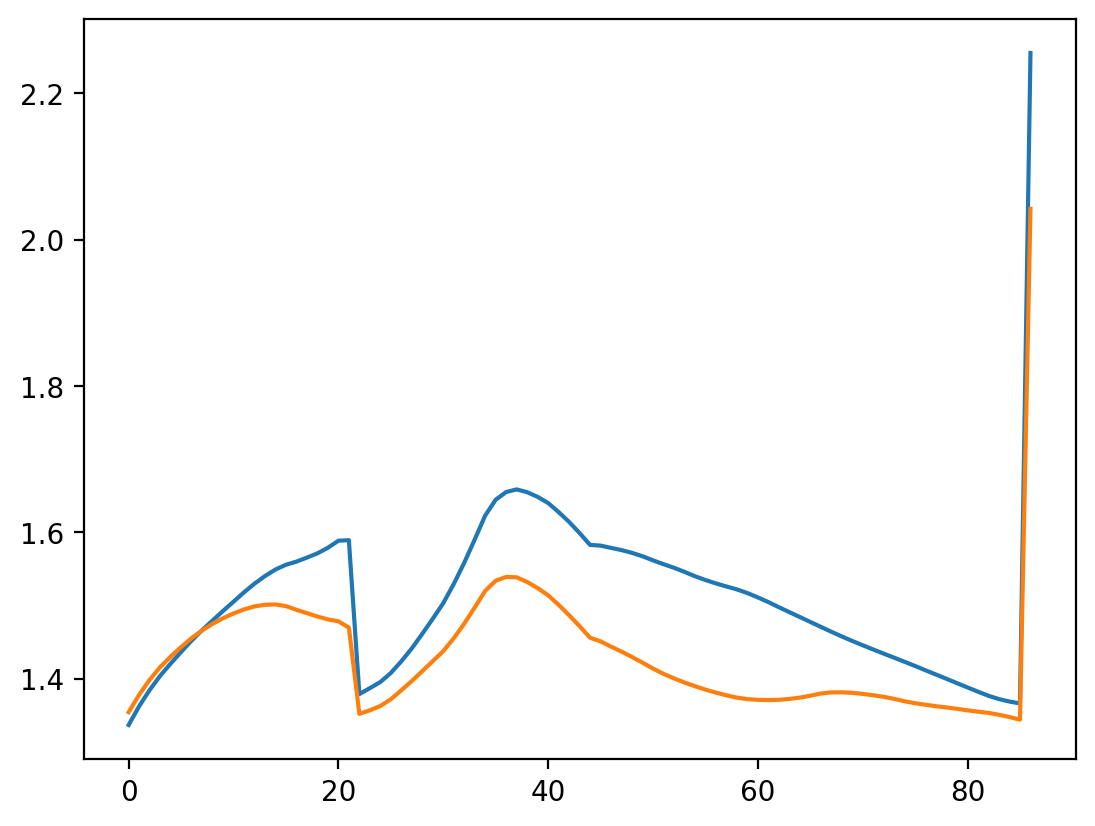

In [610]:
plt.plot(genome_deconvolution.combined_model.deconvolved_f_value.mean(axis=1)*b)
plt.plot(genome_deconvolution_no_cc.combined_model.deconvolved_f_value.mean(axis=1))